In [1]:
from transformers import GPT2Model, GPT2Tokenizer, BertModel, BertTokenizer

In [2]:
gpt2 = GPT2Model.from_pretrained("gpt2")
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

bert = BertModel.from_pretrained("bert-base-uncased")
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [3]:
be = gpt2_tokenizer.encode("banana")
# print(be)
db = [gpt2_tokenizer.decode([e]) for e in be ]
# print(db)

gtp2E = gpt2.wte.weight.detach()
# print(gtp2E.shape)

# print(gtp2E[23].unsqueeze(0).shape)

[0.5497899]


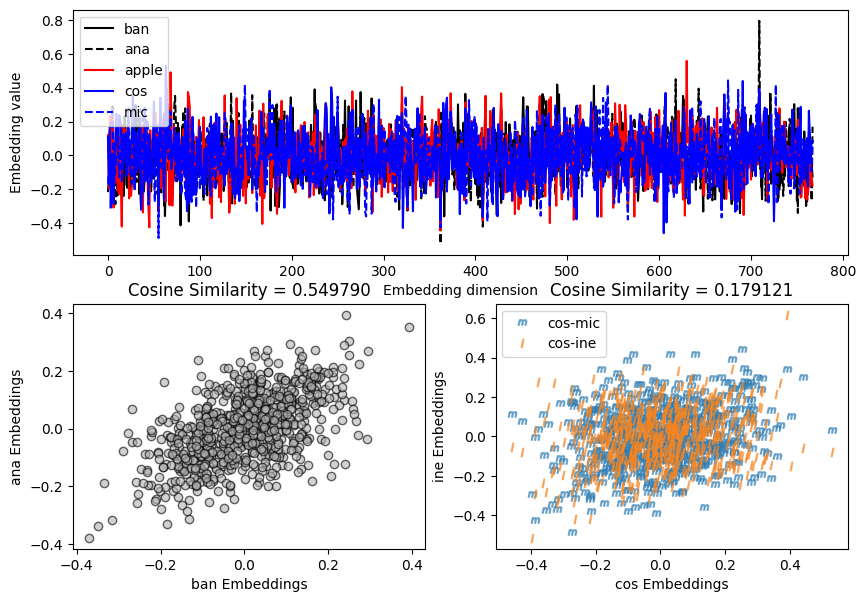

In [4]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import torch


words = ['banana', 'apple', 'cosmic']

fig = plt.figure(figsize=(10,7))
gs = GridSpec(2,2)
ax0 = fig.add_subplot(gs[0,:])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1])

linestyles = ['-','--','-.',':']
colors = 'krb'

# embeddings of all tokens of each word
for i, word in enumerate(words):
    wtkns = gpt2_tokenizer.encode(word)
    for j in range(len(wtkns)):
        ax0.plot(gtp2E[wtkns[j], :], linestyle=linestyles[j], color=colors[i], label=gpt2_tokenizer.decode(wtkns[j]))
ax0.set(xlabel='Embedding dimension', ylabel='Embedding value')
ax0.legend()

# cosine similarity of ban and ana
bv = gtp2E[gpt2_tokenizer.encode(' dog')]
av = gtp2E[gpt2_tokenizer.encode(' cat')]
num = torch.sum(bv*av, dim=1).detach().numpy()  
den = np.linalg.norm(bv)*np.linalg.norm(av)
cos_sim = num/den
print(cos_sim)

ax1.plot(bv, av, 'ko', markerfacecolor=[.7, .7, .7, .6])
ax1.set(xlabel="ban Embeddings", ylabel="ana Embeddings", title="Cosine Similarity = %3f" % cos_sim[0])

# cosime simalarity comparision b/w "cos vs mic" and "cos vs ine"

for w in ['mic', 'ine']:
    cv = gtp2E[gpt2_tokenizer.encode('cos')].squeeze()
    wv = gtp2E[gpt2_tokenizer.encode(w)].squeeze()
    cos_sim = torch.sum(cv*wv).detach().numpy()/(np.linalg.norm(cv)*np.linalg.norm(wv))
    # print(cos_sim)
    ax2.plot(cv, wv, markerfacecolor=[.7, .7, .7, .6], marker=f"${w[0]}$", linestyle="none", alpha=.6, label=f"cos-{w}")
    ax2.legend()
    ax2.set(xlabel="cos Embeddings", ylabel="" + w + " Embeddings", title="Cosine Similarity = %3f" % cos_sim)


In [26]:
# Find the most similr word to target word using cosine similarity
import heapq
source = "California"
topN = 20
topN_heap = []
stidx = gpt2_tokenizer.encode(source)
sEmb = gtp2E[stidx].detach().squeeze()
print(sEmb.shape)

for i in range(gtp2E.shape[0]):
    tEmb = gtp2E[i].detach().squeeze()
    num = torch.sum(sEmb * tEmb)
    magn_mul = torch.sum(sEmb**2) * torch.sum(tEmb**2)
    den = torch.sqrt(magn_mul)
    cos_sim = (num/den).item()
    tup = (i,cos_sim)
    # print(cos_sim)
    if i < topN:
        heapq.heappush(topN_heap, tup)
    elif cos_sim > topN_heap[0][1]:
        heapq.heapreplace(topN_heap, tup)
    
tWords = []
for tp in  topN_heap:
    dw = gpt2_tokenizer.decode(tp[0])
    tWords.append(dw)
tWords.sort()
print(tWords)

torch.Size([768])
[' Alaska', ' Californ', ' Idaho', ' Missouri', ' Nevada', ' Oakland', 'Alabama', 'Arizona', 'Calif', 'California', 'Colorado', 'Florida', 'Indiana', 'Kansas', 'Los', 'Michigan', 'Minnesota', 'Oregon', 'Utah', 'Wisconsin']


In [20]:
# Different way of getting cosine sim

# np.linalg.norm(gtp2E, axis=0)
embedding_norms = torch.norm(gtp2E, dim=1, keepdim=True) # nmagnitude of each embedding of token
print("EMN shape = ", embedding_norms.shape, "EM Shape = ", gtp2E.shape)
normalized_emb = gtp2E/embedding_norms
print(normalized_emb.shape)
sEm = normalized_emb[stidx].detach()
cos_sims = (sEm @ normalized_emb.T).squeeze()
 
topToks = np.argpartition(cos_sims, -topN)[-topN:] # largest 20 indexes
tWords = []
for t in topToks:
    dw = gpt2_tokenizer.decode(t)
    tWords.append(dw)
tWords.sort()
print(tWords)


EMN shape =  torch.Size([50257, 1]) EM Shape =  torch.Size([50257, 768])
torch.Size([50257, 768])
[' Bangalore', ' Delhi', ' Gujarat', ' Hindu', ' India', ' Indian', ' Kerala', ' Maharashtra', ' Mumbai', ' Pakistan', 'Australia', 'Canada', 'China', 'Germany', 'India', 'Indian', 'Ireland', 'Italy', 'Japan', 'Pakistan']


In [24]:
model_config = gpt2.config
print(model_config)

GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.6",
  "use_cache": true,
  "vocab_size": 50257
}



In [25]:
# exercises on unembeddings
unEmbed = gtp2E.T

print(unEmbed.shape)
randUnEmbde = torch.randn(model_config.n_embd, model_config.vocab_size)
print(randUnEmbde.shape)


torch.Size([768, 50257])
torch.Size([768, 50257])


In [86]:
w = " California"
calTok = gpt2_tokenizer.encode(w)
print(calTok)
calEmbV = gtp2E[calTok[0]]
print(calEmbV.shape)

dp = calEmbV @ unEmbed
maxDPTok = dp.argmax()
print(maxDPTok)
print(gpt2_tokenizer.decode([maxDPTok]))

[3442]
torch.Size([768])
tensor(25284)
California


In [85]:
seedW = "America"
N = 10
txt = seedW+" "
for _ in range(N):
    seedTokIdx = gpt2_tokenizer.encode(seedW)
    seedEmbV = gtp2E[seedTokIdx[0]]
    # print(seedEmbV.shape)
    dp = seedEmbV @ unEmbed
    # top10DP = dp.argsort()[-10:]
    top10DP = dp.argsort(descending=True)[:10]
    # print(top10DP)
    randDP = np.random.choice(top10DP)
    nw = gpt2_tokenizer.decode([randDP])
    # print(nw)
    txt +=  nw+" "
    seedW = nw

print(txt)



America Americ America America American  AMER  Amer  Amer  Amer  Amer  misunder 
